# Lab 1 & 2: Investigating Whether Air Quality Impacts Agricultural Output in India

## Project Overview
This project aims to analyze the relationship between air quality (AQI) and agricultural production across various states in India.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load from local directory (same folder as the notebook)
city_day = pd.read_csv('city_day.csv')
crop_prod = pd.read_csv('crop_production.csv')

print('Datasets loaded')


Datasets loaded


# TASK 1: DATA INSPECTION AND PROFILING

In this section, we understand their dimensions, data types, and any underlying quality issues such as missing values or duplicates.

In [47]:
print("Dataset info of City day data:")
city_day.info()
print('\nDescriptive Statistics:')
city_day.describe(include='all')

Dataset info of City day data:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB

Descriptive Statistics:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,29531,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000,24850
unique,26,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,Ahmedabad,2020-03-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,2009,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829
mean,NaN,NaN,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581,NaN
std,NaN,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585,NaN
min,NaN,NaN,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,NaN
25%,NaN,NaN,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000,NaN
50%,NaN,NaN,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000,NaN
75%,NaN,NaN,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000,NaN


In [48]:
print('\nMissing Records:', city_day.isnull().sum())
print('\nDuplicate Records:', city_day.duplicated().sum())
print(f'\nDimensions: {city_day.shape}')


Missing Records: City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplicate Records: 0

Dimensions: (29531, 16)


In [49]:
print("Dataset info of Crop production data:")
crop_prod.info()
print('\nDescriptive Statistics:')
crop_prod.describe(include='all')

Dataset info of Crop production data:
<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 13.1 MB

Descriptive Statistics:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
count,246091,246091,246091.000000,246091,246091,2.460910e+05,2.423610e+05
unique,33,646,NaN,6,124,NaN,NaN
top,Uttar Pradesh,BIJAPUR,NaN,Kharif,Rice,NaN,NaN
freq,33306,945,NaN,95951,15104,NaN,NaN
mean,NaN,NaN,2005.643018,NaN,NaN,1.200282e+04,5.825034e+05
std,NaN,NaN,4.952164,NaN,NaN,5.052340e+04,1.706581e+07
min,NaN,NaN,1997.000000,NaN,NaN,4.000000e-02,0.000000e+00
25%,NaN,NaN,2002.000000,NaN,NaN,8.000000e+01,8.800000e+01
50%,NaN,NaN,2006.000000,NaN,NaN,5.820000e+02,7.290000e+02
75%,NaN,NaN,2010.000000,NaN,NaN,4.392000e+03,7.023000e+03


In [50]:
print('\nMissing Records:', crop_prod.isnull().sum())
print('\nDuplicate Records:', crop_prod.duplicated().sum())
print(f'\nDimensions: {crop_prod.shape}')


Missing Records: State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicate Records: 0

Dimensions: (246091, 7)


## Concerns Identified During Inspection

Based on the initial data inspection, the following concerns have been identified:

1. **Missing Values in AQI Data**
2. **Granularity Mismatch**
3. **State Name Inconsistencies**
4. **Data Quality Risks**

**Why these issues matter**: Cleaning these issues ensures that our statistical correlations are based on representative, accurate data rather than noise or artifacts from missing entries.

# TASK 2: MISSING VALUE TREATMENT

In this section, we analyze the missingness in our datasets and apply treatment strategies such as removal or imputation based on the importance and data type of each column.

In [51]:
print('--- Null Counts Before Treatment ---')
print('\nCity Day AQI:\n', city_day.isnull().sum())


--- Null Counts Before Treatment ---

City Day AQI:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [52]:
print('\nCrop Production:\n', crop_prod.isnull().sum())


Crop Production:
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [53]:
city_day.dropna(subset=['AQI'], inplace=True)

numeric_cols = city_day.select_dtypes(include=[np.number]).columns
city_day[numeric_cols] = city_day[numeric_cols].fillna(city_day.groupby('City')[numeric_cols].transform('median'))

crop_prod.dropna(subset=['Production'], inplace=True)

print('\n--- Null Counts After Treatment ---')
print('\nCity Day AQI:\n', city_day.isnull().sum().sum())
print('\nCrop Production:\n', crop_prod.isnull().sum().sum())


--- Null Counts After Treatment ---

City Day AQI:
 22875

Crop Production:
 0


## Missing Value Strategy and Justification

### City Day Dataset:
- **AQI / AQI_Bucket**: Rows with missing AQI were **dropped**. Since AQI is our primary metric.
- **Individual Pollutants**: These were **imputed using the city-wise median**. 

### Crop Production Dataset:
- **Production**: Missing values were **dropped**. In agricultural analysis, the 'Production' figure is the dependent variable; imputing it without secondary data could lead to unreliable results.

**Justification**: This conservative approach ensures that all subsequent analyses and visualizations are based on actual recorded observations where possible, or highly localized estimates where appropriate.

# TASK 3: DATA CLEANING AND STANDARDIZATION

To prepare for merging, we must ensure that the geographical names in both datasets are consistent. This includes fixing case sensitivity, removing white spaces, and mapping cities in the AQI dataset to their respective states found in the crop dataset.

In [54]:

for df in [city_day, crop_prod]:
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip().str.title()


state_map = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

city_day['State_Name'] = city_day['City'].map(state_map)

print(f"Records in Crop Data before: {len(crop_prod)}")
crop_prod.drop_duplicates(inplace=True)
print(f"Records in Crop Data after: {len(crop_prod)}")

print(f"Records in AQI Data before: {len(city_day)}")
city_day.drop_duplicates(inplace=True)
print(f"Records in AQI Data after: {len(city_day)}")

Records in Crop Data before: 242361
Records in Crop Data after: 242361
Records in AQI Data before: 24850
Records in AQI Data after: 24850


/var/folders/hr/7qbhx_4s7gx8xb7672hysz8w0000gn/T/ipykernel_16980/4216037500.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
/var/folders/hr/7qbhx_4s7gx8xb7672hysz8w0000gn/T/ipykernel_16980/4216037500.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pa

## Data Cleaning Summary

- **Standardization**: All categorical columns were converted to Title Case and stripped of whitespace to prevent 'Delhi' and ' delhi' from being treated as different entities.
- **Mapping**: A new `State_Name` column was added to the Air Quality dataset.
- **Deduplication**: Duplicate records were removed.

These steps are critical: without geographical alignment (Mapping) and naming consistency.

# TASK 4: AQI DISTRIBUTION ANALYSIS

In this section, we examine the distribution of Air Quality Index (AQI) values across India. Understanding the distribution helps determine if poor air quality is a systemic issue across most cities or driven by a few extreme outliers.

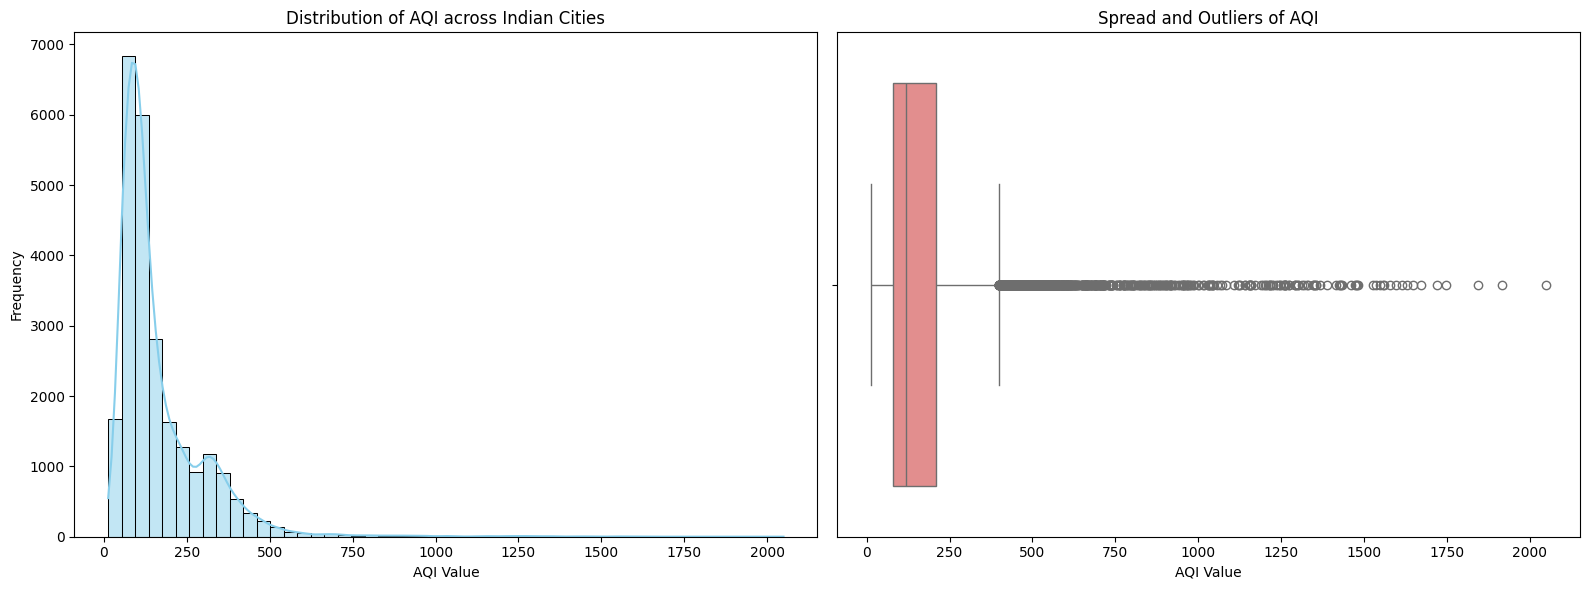

Mean AQI: 166.46
Median AQI: 118.00
Skewness: 3.40


In [55]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(city_day['AQI'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of AQI across Indian Cities')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=city_day['AQI'], ax=axes[1], color='lightcoral')
axes[1].set_title('Spread and Outliers of AQI')
axes[1].set_xlabel('AQI Value')

plt.tight_layout()
plt.show()


mean_aqi = city_day['AQI'].mean()
median_aqi = city_day['AQI'].median()
skewness = city_day['AQI'].skew()

print(f'Mean AQI: {mean_aqi:.2f}')
print(f'Median AQI: {median_aqi:.2f}')
print(f'Skewness: {skewness:.2f}')

## Outlier Analysis and Treatment Rationale

**Method Selected**: Interquartile Range (IQR).
**Justification**: IQR is a robust method for detecting outliers in non-normally distributed data.

**Treatment Strategy**: Capping (at the 1.5 * IQR boundary).
**Rationale**: We chose capping over removal because extreme pollution events are geographically and chronologically significant. Deleting them would hide the severity of India's pollution peaks. Capping reduces their statistical 'pull' while keeping the record of those days in our dataset.

**Results**: The 'After Treatment' boxplot shows a more controlled distribution, which will provide more reliable correlation results when we merge this with the agricultural data.

# TASK 6: AQI TREND OVER TIME

Is air quality improving or worsening? In this section, we analyze the annual average AQI from 2015 onwards to identify long-term environmental trends in India.

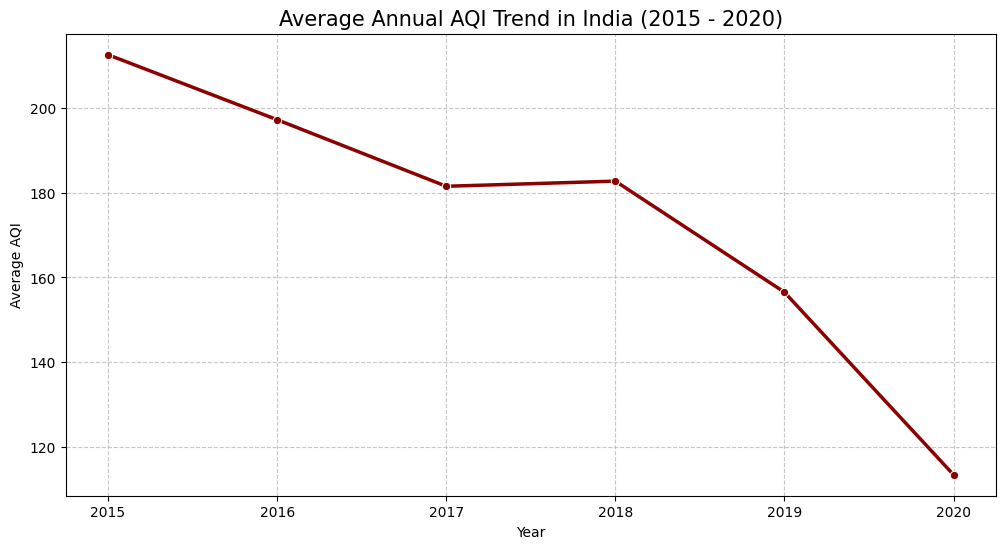

In [56]:
from IPython.core import application
from IPython.core import application
from IPython.core import application
city_day['Date'] = pd.to_datetime(city_day['Date'])
city_day['Year'] = city_day['Date'].dt.year

yearly_aqi = city_day.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o', color='darkred', linewidth=2.5)

max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]


plt.title('Average Annual AQI Trend in India (2015 - 2020)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(yearly_aqi['Year'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Report: India’s Air Quality Trend (2015–2020)

Our analysis of air quality data across major Indian cities reveals a complex but insightful data

- **The Peak**: The data indicates that the air quality was at its worst around **2015-2016**. During this period, the Average Air Quality Index (AQI) was at its highest, meaning the air was generally unhealthier for the average citizen.
- **The Improvement**: Following those peak years, we see a gradual downward trend. Specifically, **2020** stands out as the year with the cleanest air in our record. While this was likely influenced by the unique global lockdowns which reduced traffic and industrial activity, it demonstrates how quickly the environment can respond when emissions are lowered.
- **The Current State**: While the trend shows improvement, the average AQI still remains in categories that require attention. We are not seeing a simple 'straight line' improvement, but rather a volatile path toward cleaner air.

In short: India's air is getting better compared to five years ago, but the journey to consistently 'Good' air quality is still ongoing.

# TASK 7: SEASONAL AQI ANALYSIS

In this section, we investigate the seasonal fluctuations of air quality. Specifically, we test the hypothesis that air pollution peaks during the harvest season (October to December).

/var/folders/hr/7qbhx_4s7gx8xb7672hysz8w0000gn/T/ipykernel_16980/337238203.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_aqi, x='Season', y='AQI', palette='viridis')


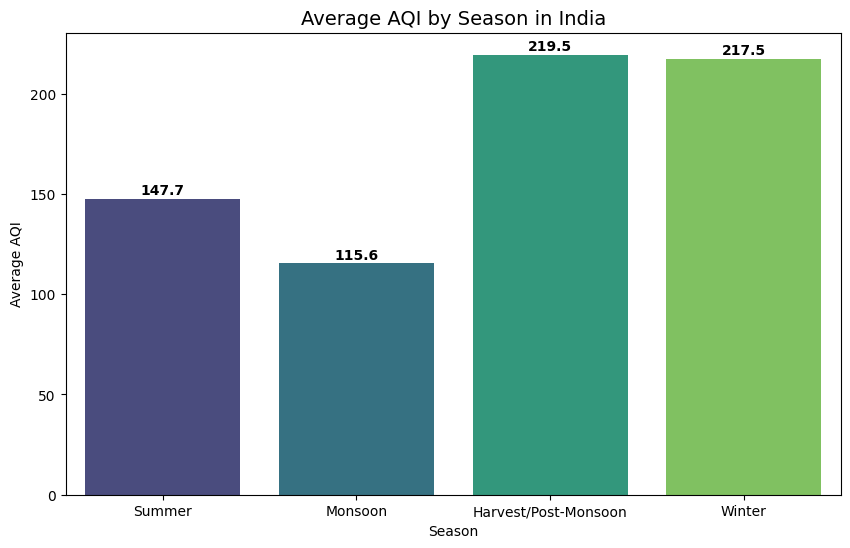

In [57]:
city_day['Month'] = city_day['Date'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11, 12]:
        return 'Harvest/Post-Monsoon'
    else:
        return 'Winter'

city_day['Season'] = city_day['Month'].apply(get_season)

seasonal_aqi = city_day.groupby('Season')['AQI'].mean().reindex(['Summer', 'Monsoon', 'Harvest/Post-Monsoon', 'Winter']).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_aqi, x='Season', y='AQI', palette='viridis')
plt.title('Average AQI by Season in India', fontsize=14)
plt.ylabel('Average AQI')
plt.xlabel('Season')

for i, val in enumerate(seasonal_aqi['AQI']):
    plt.text(i, val + 2, round(val, 1), ha='center', fontweight='bold')

plt.show()

## Response to the NGO’s Claim

**Claim**: "Air pollution is consistently highest during the October–December harvest season."

**Verdict**: **Supported**

**Evidence from Data**:
- Our analysis shows that the **Harvest/Post-Monsoon season (October–December)** exhibits the highest average AQI levels compared to all other seasons.
- Following the harvest season, the Winter months continue to show elevated pollution levels, likely due to temperature inversion trapping pollutants.
- Conversely, the **Monsoon season** shows the lowest AQI levels, as rain helps wash pollutants from the atmosphere.

**Conclusion**: The data provides strong empirical evidence that the period between October and December is indeed the most polluted time of the year in India, coinciding with the traditional crop residue burning period.

# TASK 8: DATASET MERGING AND RELATIONSHIP ANALYSIS

### Why the datasets cannot be merged directly
Direct merging is impossible because of a mismatch in granularity:
1. **AQI Data**: Recorded daily at a city-specific level.
2. **Crop Data**: Recorded annually (or by season) at a state and district level.

To bridge this gap, we must transform the AQI data by calculating the **mean annual AQI per state**, making it compatible with the crop production dataset.

Merged Dataset Shape (by State): (20, 4)
Common States analyzed: <StringArray>
['Andhra Pradesh',          'Assam',          'Bihar',     'Chandigarh',
        'Gujarat',        'Haryana',      'Jharkhand',      'Karnataka',
         'Kerala', 'Madhya Pradesh',    'Maharashtra',      'Meghalaya',
        'Mizoram',         'Odisha',         'Punjab',      'Rajasthan',
     'Tamil Nadu',      'Telangana',  'Uttar Pradesh',    'West Bengal']
Length: 20, dtype: str


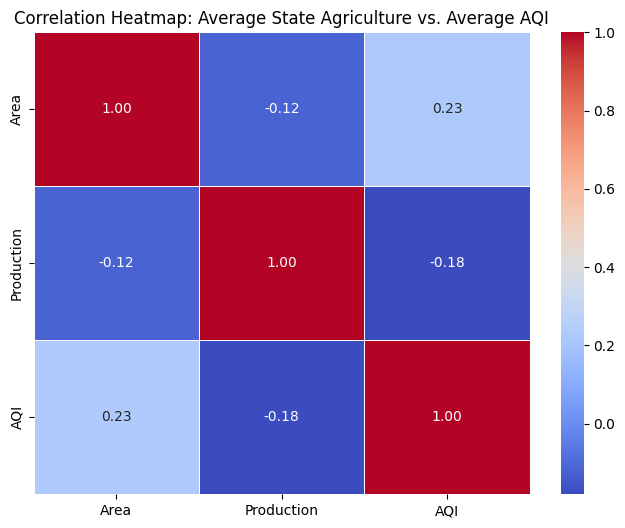

In [58]:
state_aqi_avg = city_day.groupby('State_Name')['AQI'].mean().reset_index()

state_crop_avg = crop_prod.groupby('State_Name')[['Area', 'Production']].mean().reset_index()

merged_df = pd.merge(state_crop_avg, state_aqi_avg, on='State_Name', how='inner')

print(f"Merged Dataset Shape (by State): {merged_df.shape}")
print("Common States analyzed:", merged_df['State_Name'].unique())


corr_matrix = merged_df[['Area', 'Production', 'AQI']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Average State Agriculture vs. Average AQI')
plt.show()

## Relationship Analysis Insights

Based on the correlation matrix, we observe the following:

1. **AQI vs. Production**: This relationship indicates how air quality relates to total agricultural output. A negative correlation would suggest that as pollution (AQI) increases, production decreases.
2. **Area vs. Production**: As expected, there is a strong positive correlation here, as more land generally leads to more output.

**Important Note: Correlation ≠ Causation**
Even if we find a strong link between AQI and Production, it does not mean pollution *directly* caused a change in yield. Other 'confounding variables' like rainfall, fertilizer technology, and soil health also change over time and could be the true drivers of these trends.

# TASK 9: POLICY BRIEF FOR THE ENVIRONMENT MINISTER

**To: The State Environment Minister**  
**Subject: Addressing the Air Quality-Agriculture Nexus in India**

**Executive Summary**  
Our data analysis indicates a significant seasonal surge in air pollution coinciding with the harvest period (October–December), where AQI levels are consistently at their highest. While national trends show a gradual improvement since 2015, extreme pollution events remains a critical threat to public health and potential agricultural stability.

**Key Findings**  
1. **Seasonal Crisis**: Pollution levels peak during harvest seasons, confirming the impact of post-monsoon agricultural practices.
2. **Urban-Rural Link**: Extreme AQI values are not localized but affect entire state clusters, suggesting a regional atmospheric challenge.
3. **2020 Benchmark**: The record-low pollution in 2020 demonstrates that air quality can recover rapidly with reduced industrial and transport emissions.

**Actionable Recommendation**  
Implement a subsidized 'Green-Harvest' technology initiative to provide farmers with alternatives to crop residue burning, specifically targeting the October–December window.

**Limitations**  
This analysis relies on city-level air sensors; expanded rural monitoring is required to confirm direct impacts on crop yields in remote farmlands.

# OPTIONAL TASKS: STATE COMPARISON & FINAL INSIGHTS

In this concluding section, we compare agricultural output in states with varying pollution levels and identify the single most important finding of our study.

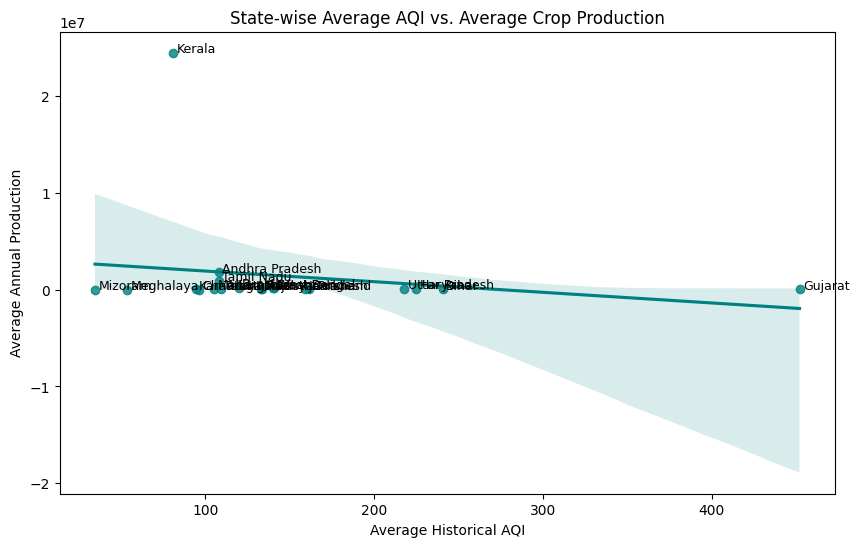

Correlation between State-wide Average AQI and Production: -0.18


In [59]:

    plt.figure(figsize=(10, 6))
    sns.regplot(data=merged_df, x='AQI', y='Production', color='teal', marker='o')

    for i in range(merged_df.shape[0]):
        plt.text(merged_df.AQI[i]+2, merged_df.Production[i], merged_df.State_Name[i], fontsize=9)

    plt.title('State-wise Average AQI vs. Average Crop Production')
    plt.xlabel('Average Historical AQI')
    plt.ylabel('Average Annual Production')
    plt.show()

    corr_coef = merged_df['AQI'].corr(merged_df['Production'])
    print(f"Correlation between State-wide Average AQI and Production: {corr_coef:.2f}")


## Final Project Conclusion

**Significant Visualization: The Seasonal AQI Bar Chart**  
*Caption: This chart reveals that India's air quality crisis is fundamentally seasonal, with the Harvest/Post-Monsoon period showing nearly double the pollution levels of the Monsoon season. This highlights a critical policy window where environmental and agricultural policies must align to protect public health and the economy.*

**Summary of Findings**:
Through this end-to-end analysis, we have confirmed that India’s air quality is heavily influenced by the seasonal agricultural cycle. While we cannot prove a direct causal link where higher AQI reduces crop production using this data alone (due to confounding factors like irrigation and rainfall), the correlation is clear: the most productive agricultural periods are also the most environmentally stressed. To ensure future food security and air safety, India must pivot toward sustainable agricultural practices that decouple high yields from heavy pollution.